# Grover's Algorithm — 10-Qubit Implementation
### Quantum Computing — Final Course Project

| | |
|---|---|
| **Author** | Sharanya C |
| **Course** | Quantum Computing |
| **Institution** | Jio Institute |
| **Project Type** | Final Course Project |


## Objective

Implement Grover's search algorithm **entirely from scratch** using Qiskit quantum gates to locate two marked elements in a **10-qubit search space** ($2^{10} = 1024$ possible bit strings). No built-in Grover implementation (`qiskit.algorithms.Grover`) is used anywhere.

| Parameter | Value |
|---|---|
| Search space | $2^{10} = 1024$ states (10 qubits) |
| Marked states | `"0110011010"` and `"1101010001"` |
| Oracle (Part A) | IBM-style — `MCMTGate(ZGate())` + open-control X-gates |
| Oracle (Part B) | Phase Kickback — MCX into ancilla $|{-}\rangle$ |
| Diffuser | Manual — $H^{\otimes n}\,X^{\otimes n}\,\mathrm{MCZ}\,X^{\otimes n}\,H^{\otimes n}$ |
| Built-in Grover | ✗ **Not used** |

**Tasks (as per project specification):**

1. Create the uniform superposition state using Hadamard gates on all $n$ qubits.
2. Implement an oracle circuit that applies a $-1$ phase to the two marked states.
3. Implement the Grover diffusion operator ($H^{\otimes n} \to U_0 \to H^{\otimes n}$).
4. Run the circuit for iteration counts $k = 1, 3, 5, 10,$ and the optimal $k$.
5. Execute on the Qiskit Aer simulator with $\geq 1024$ shots and display measurement histograms.


---
## Background — Grover's Algorithm

### Classical vs Quantum Search

Given an unsorted database of $N = 2^n$ items, finding a marked item requires:

- **Classically:** $O(N)$ queries on average — each item must be checked one by one.
- **Grover's algorithm (Grover 1996):** $O(\sqrt{N})$ quantum oracle queries — a **quadratic speedup**.

For $N = 1024$ and $M = 2$ marked states, classical search needs $\approx 512$ queries on average, while Grover's algorithm needs only **17 oracle calls**.

### High-Level Circuit Structure

$$
|0\rangle^{\otimes n}
\xrightarrow{\;H^{\otimes n}\;}
|s\rangle
\xrightarrow{\;(U_f \cdot U_s)^k\;}
|\text{marked}\rangle
$$

| Symbol | Name | Role |
|---|---|---|
| $|s\rangle$ | Uniform superposition | $\dfrac{1}{\sqrt{N}}\displaystyle\sum_{x=0}^{N-1}|x\rangle$ — equal amplitude on all $N$ states |
| $U_f$ | **Oracle** | Marks target states: $U_f|x\rangle = (-1)^{f(x)}|x\rangle$ |
| $U_s$ | **Diffuser** | Reflects amplitudes about the mean (inversion about average) |
| $k$ | Iterations | Number of times $U_f \cdot U_s$ is applied |

### Optimal Number of Iterations

For $M$ marked states out of $N$ total, define the angle:

$$
\theta = \arcsin\!\sqrt{\frac{M}{N}}
$$

The probability of measuring a marked state after $k$ Grover iterations is:

$$
P_{\mathrm{success}}(k) = \sin^2\!\bigl((2k+1)\,\theta\bigr)
$$

This is maximised at the optimal iteration count:

$$
k_{\mathrm{opt}} = \left\lfloor \frac{\pi}{4\theta} \right\rfloor
$$


---
## Mathematical Framework

### Oracle $U_f$ — Phase Flip on Marked States

For a marked state $|\omega\rangle$, the oracle applies a $-1$ relative phase to that state alone while leaving all other states unchanged:

$$
U_f = I - 2|\omega\rangle\langle\omega|
\qquad\Rightarrow\qquad
U_f|x\rangle =
\begin{cases}
-|x\rangle & x = \omega \\
+|x\rangle & x \neq \omega
\end{cases}
$$

**Open-control implementation trick:**

1. For each bit `'0'` in the target bit-string, apply an X gate on that qubit (temporarily flipping it to $|1\rangle$).
2. Apply a Multi-Controlled-Z (MCZ) gate — this flips the phase **only** when every qubit is $|1\rangle$.
3. Undo the X gates to restore the original qubit values.

Net effect: only the target state $|\omega\rangle$ receives the $-1$ phase.

### Diffuser $U_s$ — Inversion About the Mean

The diffuser reflects every amplitude about the mean amplitude. It can be written as:

$$
U_s = 2|s\rangle\langle s| - I = H^{\otimes n}\bigl(2|0\rangle\langle 0| - I\bigr)H^{\otimes n}
$$

Equivalently, $U_s = H^{\otimes n} \cdot U_0 \cdot H^{\otimes n}$, where $U_0$ flips the phase of every basis state **except** $|0\cdots0\rangle$:

$$
U_0 = 2|0\rangle\langle 0| - I
$$

**Gate implementation:**

$$
H^{\otimes n}
\;\xrightarrow{X^{\otimes n}}\;
\xrightarrow{\mathrm{MCZ}}\;
\xrightarrow{X^{\otimes n}}\;
H^{\otimes n}
$$

where $\mathrm{MCZ} = H_{n-1} \cdot \mathrm{MCX}(0,\ldots,n{-}2 \to n{-}1) \cdot H_{n-1}$ (Hadamard on the last qubit converts a multi-controlled-X into a multi-controlled-Z).


---
## Setup & Imports

In [1]:
# Standard library
import math

# Qiskit core
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import MCMTGate, ZGate   # MCMTGate used only in Part A oracle
from qiskit.visualization import plot_histogram

# Local Aer simulator
from qiskit_aer import Aer

# Plotting utilities
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")


All imports successful ✓


---
## Problem Setup

### 10-Qubit Search Space

| Parameter | Value |
|---|---|
| Number of qubits $n$ | **10** |
| Total states $N = 2^n$ | **1024** |
| Marked states $M$ | **2** |
| Marked state 1 | `"0110011010"` → decimal 410 |
| Marked state 2 | `"1101010001"` → decimal 849 |
| Shots per run | **8192** (≥ 1024 as required) |

### Optimal Iteration Count

$$
\theta = \arcsin\!\sqrt{\frac{2}{1024}} \approx 0.0442 \text{ rad}
\qquad
k_{\mathrm{opt}} = \left\lfloor\frac{\pi}{4 \times 0.0442}\right\rfloor = 17
$$

In addition to the optimal $k = 17$, we run the circuit at $k = 1, 3, 5, 10$ to observe how amplitude amplification builds up iteration by iteration.


In [2]:
# ── Problem parameters ──────────────────────────────────────────────────────
NUM_QUBITS    = 10
marked_states = ["0110011010", "1101010001"]   # the two target bit-strings
SHOTS         = 8192                           # number of measurement shots

# ── Derived quantities ───────────────────────────────────────────────────────
N     = 2 ** NUM_QUBITS          # total size of the search space
M     = len(marked_states)       # number of marked (target) states

# Grover angle and optimal iteration count
theta = math.asin(math.sqrt(M / N))
k_opt = math.floor(math.pi / (4 * theta))

# Iteration counts to study (project requires 1, 3, 5, 10 plus the optimal)
ITER_COUNTS = [1, 3, 5, 10, k_opt]

# ── Print summary ────────────────────────────────────────────────────────────
print(f"Number of qubits  : {NUM_QUBITS}")
print(f"Search space size : 2^{NUM_QUBITS} = {N}")
print(f"Marked states ({M}) :")
for s in marked_states:
    print(f"  '{s}'  →  decimal {int(s, 2):<5}")

print(f"\nθ = arcsin(√(M/N)) = arcsin(√({M}/{N})) = {theta:.6f} rad")
print(f"k_opt = ⌊π / (4θ)⌋ = ⌊{math.pi/(4*theta):.4f}⌋ = {k_opt}")
print(f"\nIteration counts to study: {ITER_COUNTS}")

print(f"\n{'k':>5}  {'P(marked) — theory':>20}")
print("─" * 28)
for k in ITER_COUNTS:
    p    = math.sin((2*k + 1)*theta)**2
    flag = "  ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p:>20.4f}{flag}")


Number of qubits  : 10
Search space size : 2^10 = 1024
Marked states (2) :
  '0110011010'  →  decimal 410  
  '1101010001'  →  decimal 849  

θ = arcsin(√(M/N)) = arcsin(√(2/1024)) = 0.044209 rad
k_opt = ⌊π / (4θ)⌋ = ⌊17.7657⌋ = 17

Iteration counts to study: [1, 3, 5, 10, 17]

    k    P(marked) — theory
────────────────────────────
    1                0.0175
    3                0.0927
    5                0.2184
   10                0.6410
   17                0.9994  ← optimal


---
---
# Section 1 — Oracle Construction

The **oracle** is the quantum gate that encodes the search problem. It applies a $-1$ phase to every marked state and leaves all other states unchanged.

We implement two independent oracle variants:

- **Part A:** IBM-style oracle — uses `MCMTGate(ZGate(), ...)` (adapted from the IBM Quantum tutorial)
- **Part B:** Custom Phase Kickback oracle — built entirely from elementary gates using an ancilla qubit

Both variants produce the same phase-flip effect on the marked states and satisfy the requirement that **no built-in Grover implementation is used**.


---
## Part A — IBM-Style Oracle (`MCMTGate`)

This oracle is adapted from the IBM Quantum Learning tutorial on Grover's algorithm. It uses `MCMTGate(ZGate(), n-1, 1)` to realise a multi-controlled-Z (MCZ) gate, combined with X-gates on the bit positions where the target string has a `'0'` (the "open-control trick").

**Reference:** https://quantum.cloud.ibm.com/docs/en/tutorials/grovers-algorithm


In [3]:
def grover_oracle(marked_states):
    """
    Grover oracle — IBM documentation style.

    For each marked state the function:
      1. Applies X gates on qubits where the target bit-string has '0'
         (open-control trick: converts 0-controls into 1-controls).
      2. Applies MCMTGate(ZGate(), n-1, 1) — a multi-controlled-Z that
         flips the phase whenever ALL n qubits are |1⟩.
      3. Undoes the X gates to restore the original qubit values.

    Because Qiskit uses little-endian qubit ordering, the target bit-string
    is reversed before indexing.

    Parameters
    ----------
    marked_states : str or list[str]
        Binary bit-string(s) identifying the states to phase-flip.
        All strings must have the same length.

    Returns
    -------
    QuantumCircuit
        An n-qubit oracle circuit (no ancilla).
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle A\n(IBM-style)')

    for target in marked_states:
        # Qiskit little-endian: reverse the bit-string so qubit 0 ↔ bit[-1]
        rev_target = target[::-1]

        # Positions where the target has '0' — these need an X gate
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']

        if zero_inds:
            qc.x(zero_inds)    # flip '0' qubits temporarily to |1⟩

        # MCZ: phase flip when every qubit is |1⟩
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)

        if zero_inds:
            qc.x(zero_inds)    # undo the temporary flips

    return qc


Oracle A (IBM-style)
  Qubits     : 10
  Depth      : 6
  Gate count : OrderedDict({'x': 20, 'mcmt': 2})
  Marks      : ['0110011010', '1101010001']


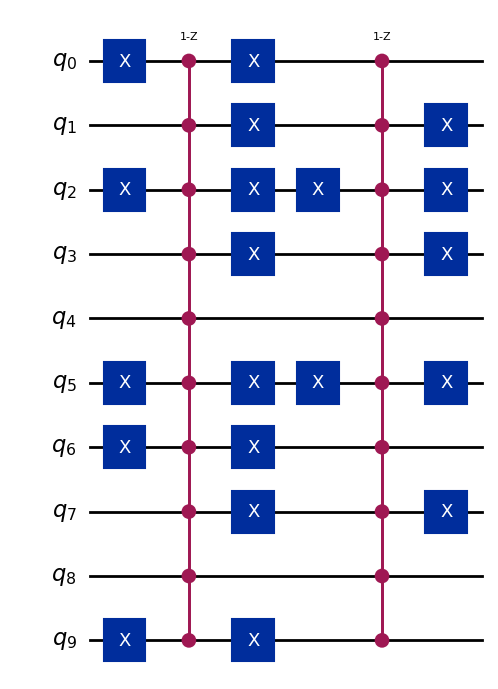

In [4]:
# Build and inspect the Part A oracle
oracle_A = grover_oracle(marked_states)

print("Oracle A (IBM-style)")
print(f"  Qubits     : {oracle_A.num_qubits}")
print(f"  Depth      : {oracle_A.depth()}")
print(f"  Gate count : {oracle_A.count_ops()}")
print(f"  Marks      : {marked_states}")

oracle_A.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 2 — Grover Diffusion Operator (Manual Construction)

The diffuser implements **inversion about the mean** and is **identical** for both Part A and Part B — it operates only on the $n$ data qubits.

$$
U_s = H^{\otimes n} \cdot U_0 \cdot H^{\otimes n}
$$

$U_0$ flips the phase of every state **except** $|0\cdots0\rangle$, and is implemented as:

$$
X^{\otimes n} \;\to\; \mathrm{MCZ} \;\to\; X^{\otimes n}
$$

where $\mathrm{MCZ} = H_{n-1} \cdot \mathrm{MCX}(0,\ldots,n{-}2 \to n{-}1) \cdot H_{n-1}$.

> **Note:** This diffuser is built entirely from elementary gates. No `grover_operator()` or any other built-in Grover helper is used.


In [5]:
def grover_diffuser(num_qubits):
    """
    Grover diffusion operator — inversion about the mean.

    Implements U_s = H^⊗n · U_0 · H^⊗n where U_0 = 2|0⟩⟨0| − I.

    Full gate sequence:
        H^⊗n  →  X^⊗n  →  H_{n-1}  →  MCX(0..n-2 → n-1)  →  H_{n-1}  →  X^⊗n  →  H^⊗n

    The inner block  H · MCX · H  realises a Multi-Controlled-Z (MCZ) gate:
    wrapping MCX's target qubit with Hadamard gates converts bit-flip into phase-flip.

    Parameters
    ----------
    num_qubits : int
        Number of data qubits (same as the oracle width).

    Returns
    -------
    QuantumCircuit
        A num_qubits-wide diffuser circuit built from elementary gates.
    """
    qc = QuantumCircuit(num_qubits, name='Diffuser')

    # Step 1: rotate to the Hadamard basis
    qc.h(range(num_qubits))
    qc.barrier(label='H⊗n')

    # Step 2: flip all qubits so |0…0⟩ maps to |1…1⟩
    qc.x(range(num_qubits))
    qc.barrier(label='X⊗n')

    # Step 3: MCZ via H · MCX · H on the last qubit
    #   - H on qubit n-1 converts the MCX bit-flip target into a phase-flip target
    qc.h(num_qubits - 1)
    qc.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    qc.h(num_qubits - 1)
    qc.barrier(label='MCZ')

    # Step 4: undo the X flip to restore all qubits
    qc.x(range(num_qubits))
    qc.barrier(label='X⊗n')

    # Step 5: rotate back to the computational basis
    qc.h(range(num_qubits))

    return qc


Grover Diffuser (manual construction)
  Qubits     : 10
  Depth      : 7
  Gate count : OrderedDict({'h': 22, 'x': 20, 'barrier': 4, 'mcx': 1})


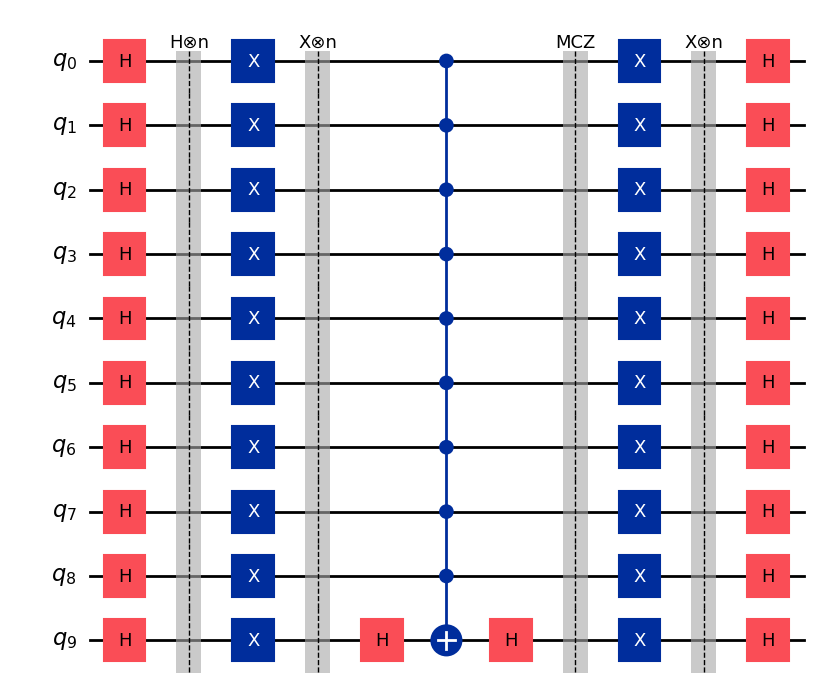

In [6]:
# Build and inspect the diffuser
diffuser = grover_diffuser(NUM_QUBITS)

print("Grover Diffuser (manual construction)")
print(f"  Qubits     : {diffuser.num_qubits}")
print(f"  Depth      : {diffuser.depth()}")
print(f"  Gate count : {diffuser.count_ops()}")

diffuser.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 3 — Custom Phase Kickback Oracle (Part B)

This is a **completely different oracle** built from scratch using only elementary gates. Instead of a direct multi-controlled-Z, it exploits the **Phase Kickback** principle.

**Key idea:** Prepare an ancilla qubit in the state

$$
|{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

and use it as the **target** of a multi-controlled-X (MCX) gate. When the data register holds the marked state $|\omega\rangle$, the MCX flips the ancilla:

$$
X|{-}\rangle = \frac{|1\rangle - |0\rangle}{\sqrt{2}} = -|{-}\rangle
$$

The $-1$ phase **kicks back** into the data register, achieving the same $-1$ phase flip as a direct MCZ — without ever using a multi-controlled-Z gate.

$$
\mathrm{MCX}\,|x\rangle|{-}\rangle =
\begin{cases}
-|x\rangle|{-}\rangle & \text{if } x = \omega \\
+|x\rangle|{-}\rangle & \text{otherwise}
\end{cases}
$$

After processing all marked states, the ancilla is **uncomputed** back to $|0\rangle$ so it can be safely ignored at measurement time.


In [7]:
def grover_oracle_kickback(marked_states):
    """
    Custom Grover oracle using Phase Kickback.

    Uses n + 1 qubits:
      - Qubits 0 … n-1  : data register  (n = NUM_QUBITS)
      - Qubit  n        : ancilla qubit   (prepared and returned to |0⟩)

    Procedure
    ---------
    1. Prepare ancilla:  |0⟩ ─X─H─▶  |−⟩
    2. For each marked state ω:
         a. X gates on qubits where ω has '0'   (open-control trick)
         b. MCX(data qubits → ancilla)           (kicks -1 phase back)
         c. X gates (undo step a)
    3. Uncompute ancilla:  |−⟩ ─H─X─▶  |0⟩

    The ancilla is NOT measured; only the 10 data qubits are measured.

    Parameters
    ----------
    marked_states : str or list[str]
        Binary bit-string(s) to phase-flip.

    Returns
    -------
    QuantumCircuit
        (n+1)-qubit oracle circuit; ancilla starts and ends in |0⟩.
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    ancilla    = num_qubits          # ancilla is the last qubit

    qc = QuantumCircuit(num_qubits + 1, name='Oracle B\n(Kickback)')

    # ── Step 1: Prepare ancilla in |−⟩ ─────────────────────────────────────
    qc.x(ancilla)      # |0⟩  →  |1⟩
    qc.h(ancilla)      # |1⟩  →  |−⟩ = (|0⟩ − |1⟩)/√2
    qc.barrier(label='anc |−⟩')

    # ── Step 2: Phase-flip each marked state via kickback ───────────────────
    for target in marked_states:
        rev_target = target[::-1]   # little-endian qubit ordering

        # Positions where target has '0' — need a temporary X flip
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']

        if zero_inds:
            qc.x(zero_inds)         # open-control: '0'-positions → |1⟩

        # MCX: all data qubits control the ancilla
        # When data == |ω⟩, MCX flips |−⟩ → −|−⟩ and the -1 phase kicks back
        qc.mcx(list(range(num_qubits)), ancilla)

        if zero_inds:
            qc.x(zero_inds)         # undo temporary flips

        qc.barrier(label=f'|{target}⟩')

    # ── Step 3: Uncompute ancilla back to |0⟩ ───────────────────────────────
    qc.h(ancilla)      # |−⟩  →  |1⟩
    qc.x(ancilla)      # |1⟩  →  |0⟩

    return qc


Oracle B (Phase Kickback)
  Total qubits (data + ancilla) : 11
  Depth                         : 10
  Gate count                    : OrderedDict({'x': 22, 'barrier': 3, 'h': 2, 'mcx': 2})
  Ancilla qubit index           : 10  (not measured; returns to |0⟩)


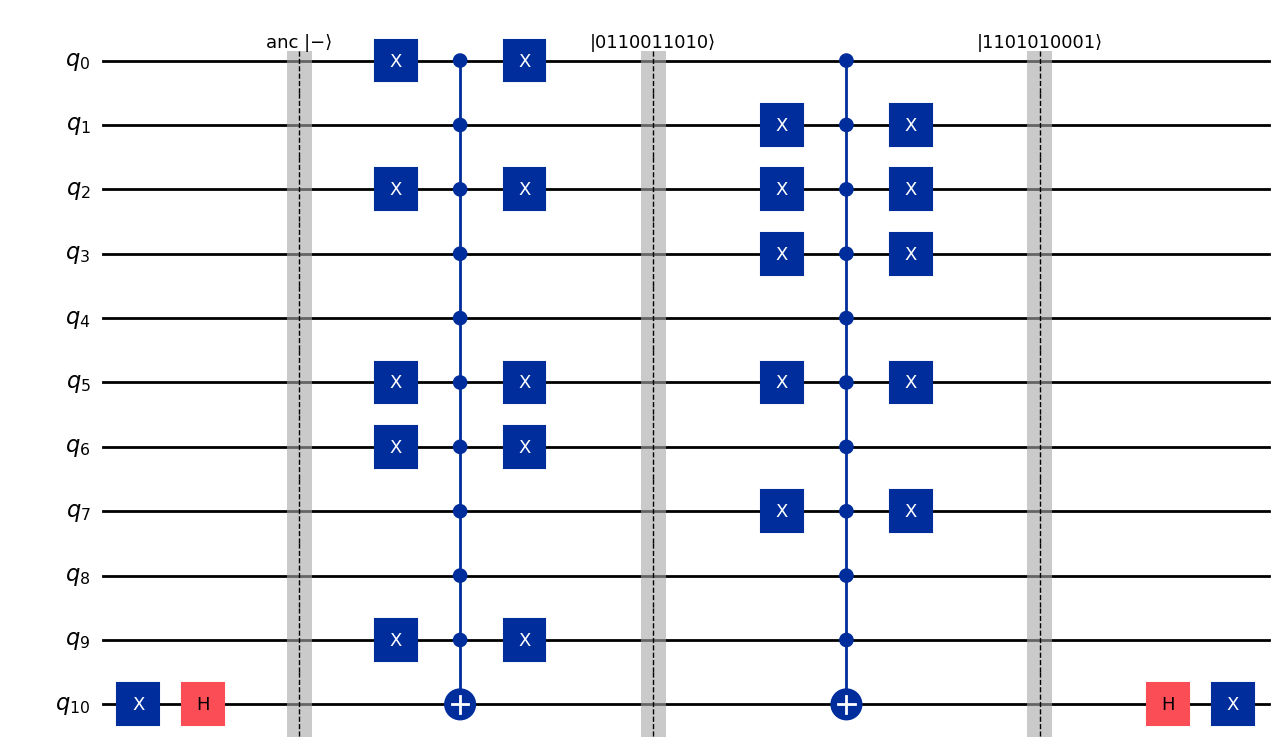

In [8]:
# Build and inspect the Part B oracle
oracle_B = grover_oracle_kickback(marked_states)

print("Oracle B (Phase Kickback)")
print(f"  Total qubits (data + ancilla) : {oracle_B.num_qubits}")
print(f"  Depth                         : {oracle_B.depth()}")
print(f"  Gate count                    : {oracle_B.count_ops()}")
print(f"  Ancilla qubit index           : {NUM_QUBITS}  (not measured; returns to |0⟩)")

oracle_B.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 4 — Grover Circuit Builder

A single helper function assembles the **full Grover search circuit** for any oracle and any number of iterations. This cleanly separates the Grover iteration loop from the oracle and diffuser definitions, making it easy to swap in different components.

Circuit structure:

$$
|0\rangle^{\otimes n}
\;\xrightarrow{H^{\otimes n}}\;
|s\rangle
\;\xrightarrow{[U_f \cdot U_s]^k}\;
\xrightarrow{\mathrm{Measure}}\;
\text{classical bitstring}
$$


In [9]:
def build_grover_circuit(oracle_circ, diffuser_circ, num_iterations,
                         num_data_qubits, has_ancilla=False):
    """
    Assemble a complete Grover search circuit.

    The circuit applies:
      1. Hadamard on all data qubits  →  uniform superposition |s⟩
      2. k repetitions of (Oracle · Diffuser)
      3. Measurement of all data qubits into a classical register

    Parameters
    ----------
    oracle_circ     : QuantumCircuit
        Oracle sub-circuit (width = num_data_qubits or num_data_qubits + 1).
    diffuser_circ   : QuantumCircuit
        Diffuser sub-circuit (width = num_data_qubits).
    num_iterations  : int
        Number of Grover iterations k.
    num_data_qubits : int
        Number of data qubits n.
    has_ancilla     : bool
        True if the oracle uses one additional ancilla qubit.

    Returns
    -------
    QuantumCircuit
        Full Grover circuit ready for simulation.
    """
    total_qubits = num_data_qubits + (1 if has_ancilla else 0)

    # One classical bit per data qubit; ancilla is NOT measured
    qc = QuantumCircuit(total_qubits, num_data_qubits)

    # ── 1. Initialise: uniform superposition on data qubits ─────────────────
    qc.h(range(num_data_qubits))
    qc.barrier(label='Init |s⟩')

    # ── 2. Grover iterations ─────────────────────────────────────────────────
    for k in range(num_iterations):
        # Oracle acts on all qubits (including ancilla if present)
        qc.compose(oracle_circ,   qubits=range(total_qubits),    inplace=True)
        # Diffuser acts on data qubits only
        qc.compose(diffuser_circ, qubits=range(num_data_qubits), inplace=True)
        qc.barrier(label=f'Iter {k+1}')

    # ── 3. Measure data qubits ───────────────────────────────────────────────
    qc.measure(range(num_data_qubits), range(num_data_qubits))

    return qc


In [10]:
# Initialise the Aer simulator backend
backend = Aer.get_backend('aer_simulator')


---
---
# Section 5 — Part A: Multi-Iteration Experiment (IBM-Style Oracle)

We run the Grover circuit with the **IBM-style oracle** for each required iteration count $k \in \{1, 3, 5, 10, 17\}$.

> **Transpilation note:** `MCMTGate` is a high-level composite gate. Qiskit Aer cannot execute it directly; we call `transpile(qc, backend)` first to decompose it into Aer's supported basis gates (`cx`, `u`, `x`, `h`, `measure`). The resulting circuit is electrically equivalent but may be significantly deeper than the abstract representation.


In [11]:
results_A = {}   # maps k → counts dict

print("Running Part A (IBM-style oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Note'}")
print("─" * 45)

for k in ITER_COUNTS:
    # Build the full Grover circuit for this iteration count
    qc_k = build_grover_circuit(
        oracle_circ     = oracle_A,
        diffuser_circ   = diffuser,
        num_iterations  = k,
        num_data_qubits = NUM_QUBITS,
        has_ancilla     = False
    )

    # Transpile to decompose high-level gates (MCMTGate) into basis gates
    qc_k_t = transpile(qc_k, backend, optimization_level=1)

    # Run simulation
    job    = backend.run(qc_k_t, shots=SHOTS)
    counts = job.result().get_counts()
    results_A[k] = counts

    # Compare theory vs simulation
    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    flag     = "  ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part A (IBM-style oracle)...
    k   P(theory)      P(sim)  Note
─────────────────────────────────────────────
    1      0.0175      0.0146
    3      0.0927      0.0931
    5      0.2184      0.2185
   10      0.6410      0.6521
   17      0.9994      0.9999  ← optimal

Done ✓


### Part A Results — Measurement Histograms Across Iteration Counts

Each panel shows the full measurement distribution over all 1024 basis states for one value of $k$. The two **marked states are highlighted in red**. Notice how the red bars grow progressively taller as $k$ increases toward the optimum.


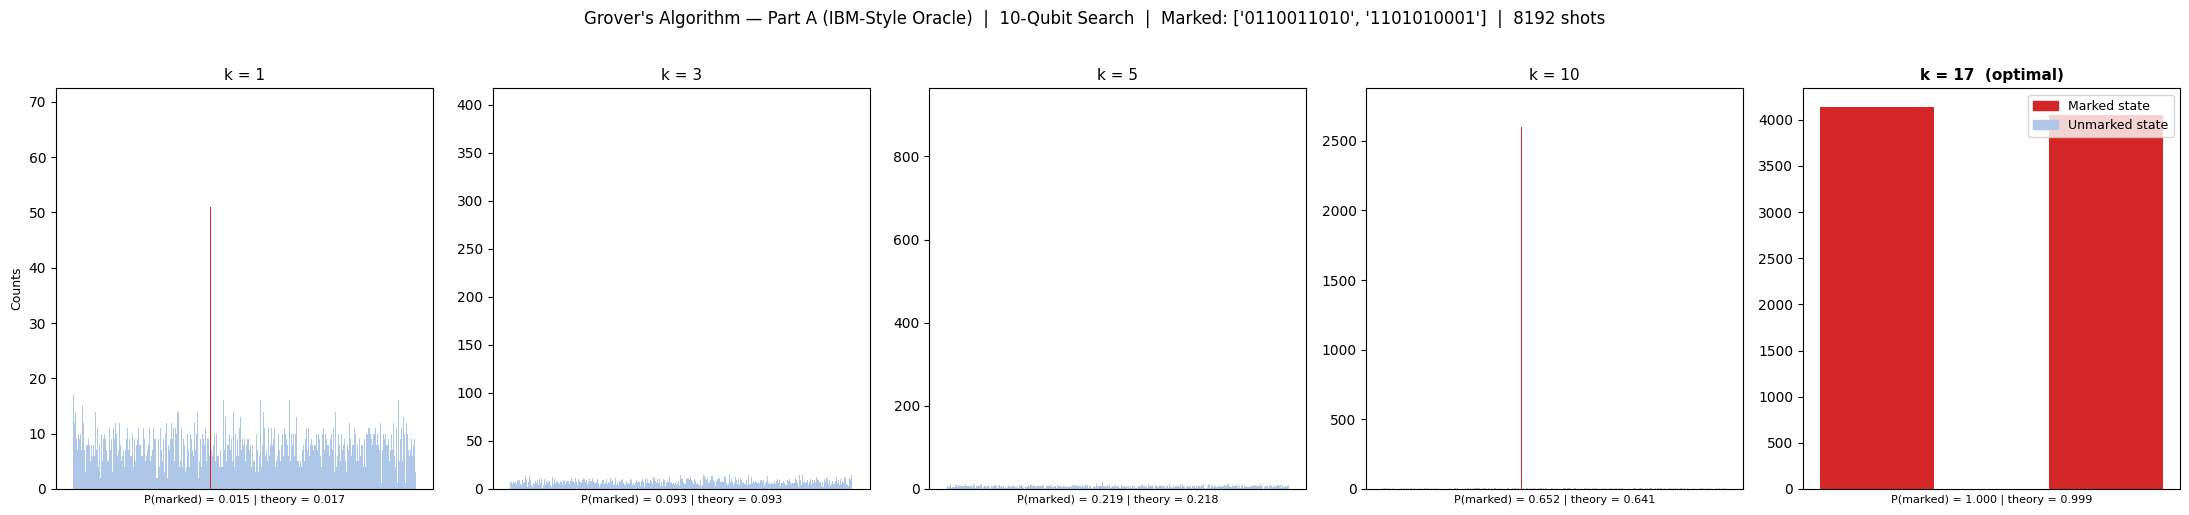

In [12]:
fig, axes = plt.subplots(1, len(ITER_COUNTS), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, ITER_COUNTS):
    counts      = results_A[k]
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#d62728' if s in marked_states else '#aec7e8'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2

    title = f"k = {k}{'  (optimal)' if k == k_opt else ''}"
    ax.set_title(title,
                 fontsize=11,
                 fontweight='bold' if k == k_opt else 'normal')
    ax.set_xlabel(f"P(marked) = {p_sim:.3f} | theory = {p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax is axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm — Part A (IBM-Style Oracle)  |  "
    f"10-Qubit Search  |  Marked: {marked_states}  |  {SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#d62728', label='Marked state'),
    mpatches.Patch(color='#aec7e8', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part A — Detailed Top Results at Optimal Iterations ($k = 17$)

In [13]:
counts_opt_A = results_A[k_opt]
top_A        = sorted(counts_opt_A.items(), key=lambda x: -x[1])[:10]

print(f"Part A — k = {k_opt} (optimal)  |  {SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_A:
    prob    = cnt / SHOTS
    is_mark = "✓ MARKED" if bitstr in marked_states else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_A = sum(counts_opt_A.get(s, 0) for s in marked_states) / SHOTS
p_th_A  = math.sin((2*k_opt + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_A:.4f}  ({p_sim_A*100:.2f}%)")
print(f"P(any marked)  theory     = {p_th_A:.4f}  ({p_th_A*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_A - p_th_A):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_A > 0.8 else 'needs review ✗'}")


Part A — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  0110011010     4134        0.5046  ✓ MARKED
  1101010001     4057        0.4952  ✓ MARKED
  1000000010        1        0.0001  

P(any marked)  simulated  = 0.9999  (99.99%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0004

Result: Algorithm SUCCEEDED ✓


---
---
# Section 6 — Part B: Multi-Iteration Experiment (Phase Kickback Oracle)

The same multi-iteration experiment is now run using the **Phase Kickback oracle**. The circuit has **11 qubits** in total (10 data + 1 ancilla), but only the 10 data qubits are measured.

> **Implementation note:** `.compose()` is used to insert sub-circuits rather than `.to_gate()`, because sub-circuits that contain `barrier` instructions cannot be converted to `Gate` objects (barriers have no unitary matrix). `.compose()` inlines all sub-circuit instructions — including barriers — directly, which works correctly in all cases.


In [14]:
results_B = {}   # maps k → counts dict

print("Running Part B (Phase Kickback oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Note'}")
print("─" * 45)

for k in ITER_COUNTS:
    qc_k = build_grover_circuit(
        oracle_circ     = oracle_B,
        diffuser_circ   = diffuser,
        num_iterations  = k,
        num_data_qubits = NUM_QUBITS,
        has_ancilla     = True          # oracle_B has 1 ancilla qubit
    )

    # Transpile to basis gates before running
    qc_k_t = transpile(qc_k, backend, optimization_level=1)

    job    = backend.run(qc_k_t, shots=SHOTS)
    counts = job.result().get_counts()
    results_B[k] = counts

    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    flag     = "  ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part B (Phase Kickback oracle)...
    k   P(theory)      P(sim)  Note
─────────────────────────────────────────────
    1      0.0175      0.0181
    3      0.0927      0.0958
    5      0.2184      0.2162
   10      0.6410      0.6379
   17      0.9994      0.9994  ← optimal

Done ✓


### Part B Results — Measurement Histograms Across Iteration Counts

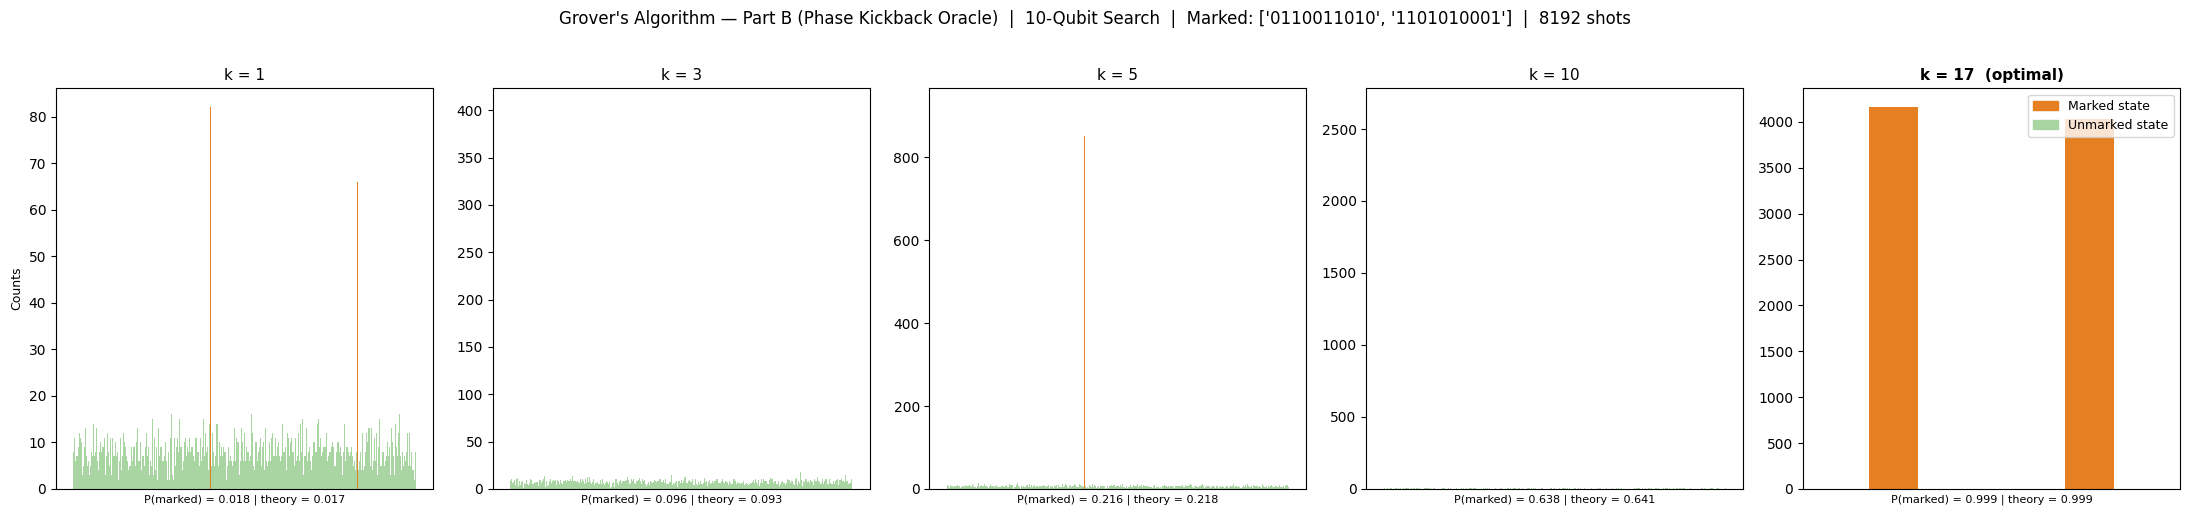

In [15]:
fig, axes = plt.subplots(1, len(ITER_COUNTS), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, ITER_COUNTS):
    counts      = results_B[k]
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#e67e22' if s in marked_states else '#a8d5a2'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2

    title = f"k = {k}{'  (optimal)' if k == k_opt else ''}"
    ax.set_title(title,
                 fontsize=11,
                 fontweight='bold' if k == k_opt else 'normal')
    ax.set_xlabel(f"P(marked) = {p_sim:.3f} | theory = {p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax is axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm — Part B (Phase Kickback Oracle)  |  "
    f"10-Qubit Search  |  Marked: {marked_states}  |  {SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#e67e22', label='Marked state'),
    mpatches.Patch(color='#a8d5a2', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part B — Detailed Top Results at Optimal Iterations ($k = 17$)

In [16]:
counts_opt_B = results_B[k_opt]
top_B        = sorted(counts_opt_B.items(), key=lambda x: -x[1])[:10]

print(f"Part B — k = {k_opt} (optimal)  |  {SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_B:
    prob    = cnt / SHOTS
    is_mark = "✓ MARKED" if bitstr in marked_states else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_B = sum(counts_opt_B.get(s, 0) for s in marked_states) / SHOTS
p_th_B  = math.sin((2*k_opt + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_B:.4f}  ({p_sim_B*100:.2f}%)")
print(f"P(any marked)  theory     = {p_th_B:.4f}  ({p_th_B*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_B - p_th_B):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_B > 0.8 else 'needs review ✗'}")


Part B — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  0110011010     4158        0.5076  ✓ MARKED
  1101010001     4029        0.4918  ✓ MARKED
  1100000010        1        0.0001  
  1000101001        1        0.0001  
  1111111110        1        0.0001  
  1100010011        1        0.0001  
  0100011000        1        0.0001  

P(any marked)  simulated  = 0.9994  (99.94%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0001

Result: Algorithm SUCCEEDED ✓


---
---
# Section 7 — Amplitude Amplification Convergence

This plot shows how the probability of measuring a marked state grows with each Grover iteration, comparing the **theoretical sine-squared curve** against the simulated values from both Part A (IBM-style oracle) and Part B (Phase Kickback oracle).

Both oracles should closely track the theoretical curve, confirming that different gate implementations of the same oracle produce the same algorithmic behaviour.


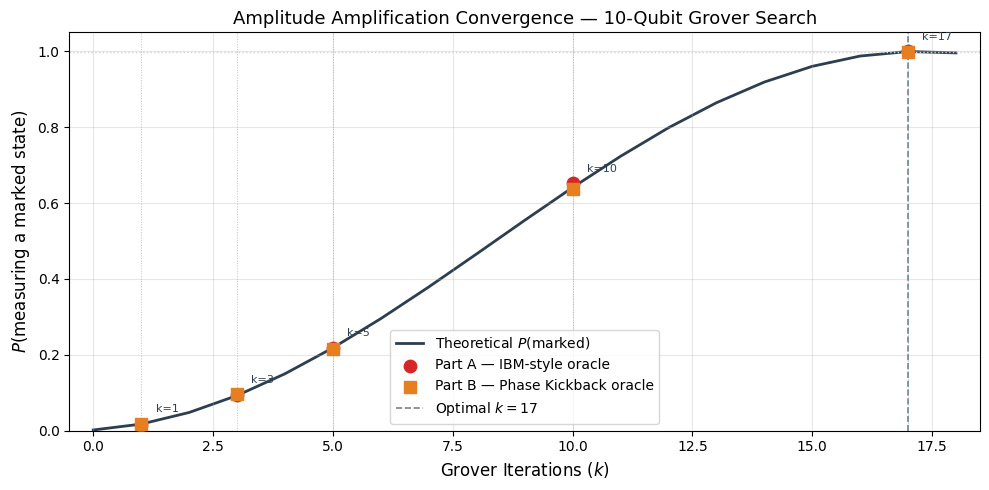

In [17]:
# Theoretical probability curve P(k) = sin²((2k+1)θ) for k = 0 … k_opt+1
all_k   = list(range(k_opt + 2))
p_curve = [math.sin((2*k + 1)*theta)**2 for k in all_k]

# Simulated probabilities at the studied iteration counts
sim_k = ITER_COUNTS
sim_A = [sum(results_A[k].get(s, 0) for s in marked_states) / SHOTS for k in sim_k]
sim_B = [sum(results_B[k].get(s, 0) for s in marked_states) / SHOTS for k in sim_k]

fig, ax = plt.subplots(figsize=(10, 5))

# Theoretical curve
ax.plot(all_k, p_curve, '-', color='#2c3e50', linewidth=2.0,
        label='Theoretical $P(\mathrm{marked})$', zorder=1)

# Simulated points
ax.scatter(sim_k, sim_A, color='#d62728', s=80, zorder=3,
           label='Part A — IBM-style oracle', marker='o')
ax.scatter(sim_k, sim_B, color='#e67e22', s=80, zorder=3,
           label='Part B — Phase Kickback oracle', marker='s')

# Mark the optimal iteration
ax.axvline(k_opt, color='gray', linestyle='--', linewidth=1.2,
           label=f'Optimal $k = {k_opt}$')
ax.axhline(p_curve[k_opt], color='lightgray', linestyle=':', linewidth=1.0)

# Highlight studied iteration counts
for k in ITER_COUNTS:
    ax.axvline(k, color='#3498db', linestyle=':', linewidth=0.7, alpha=0.5)

# Annotations for each studied k
for k, pA, pB in zip(sim_k, sim_A, sim_B):
    ax.annotate(f'k={k}',
                xy=(k, max(pA, pB)),
                xytext=(k + 0.3, max(pA, pB) + 0.03),
                fontsize=8, color='#2c3e50')

ax.set_xlabel('Grover Iterations ($k$)', fontsize=12)
ax.set_ylabel('$P$(measuring a marked state)', fontsize=12)
ax.set_title('Amplitude Amplification Convergence — 10-Qubit Grover Search', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.5, k_opt + 1.5)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
---
# Section 8 — Final Comparison: Part A vs Part B

Side-by-side histogram comparison of both oracle implementations at the optimal iteration count ($k = 17$). Both should show the two marked states dominating the distribution with probability $\approx 99.9\%$.


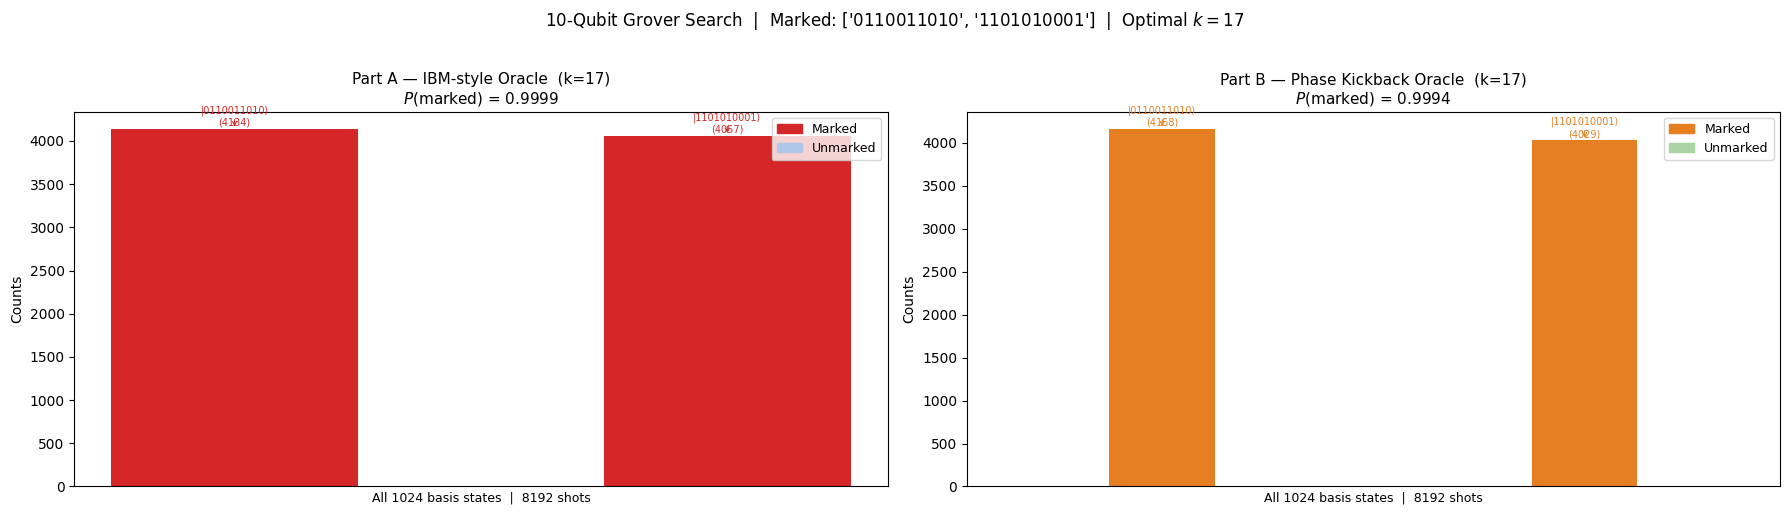

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (counts, label, mc, uc) in zip(axes, [
    (counts_opt_A,
     f"Part A — IBM-style Oracle  (k={k_opt})", '#d62728', '#aec7e8'),
    (counts_opt_B,
     f"Part B — Phase Kickback Oracle  (k={k_opt})", '#e67e22', '#a8d5a2'),
]):
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(k, 0) for k in sorted_keys]
    colours     = [mc if k in marked_states else uc for k in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    ax.set_title(f"{label}\n$P$(marked) = {p_sim:.4f}", fontsize=11)
    ax.set_xlabel(f"All {N} basis states  |  {SHOTS} shots", fontsize=9)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_xticks([])

    # Annotate each marked-state bar
    for s in marked_states:
        if s in sorted_keys:
            idx = sorted_keys.index(s)
            cnt = counts.get(s, 0)
            ax.annotate(
                f"|{s}⟩\n({cnt})",
                xy=(idx, cnt),
                xytext=(idx, cnt + 40),
                ha='center', fontsize=7, color=mc,
                arrowprops=dict(arrowstyle='->', color=mc, lw=0.8)
            )

    ax.legend(
        handles=[
            mpatches.Patch(color=mc, label='Marked'),
            mpatches.Patch(color=uc, label='Unmarked'),
        ],
        fontsize=9, loc='upper right'
    )

plt.suptitle(
    f"10-Qubit Grover Search  |  Marked: {marked_states}  |  Optimal $k = {k_opt}$",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


---
---
# Section 9 — Full Summary


In [19]:
print("=" * 72)
print("  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  COMPLETE SUMMARY")
print("=" * 72)

print(f"\n  Search space          : 2^{NUM_QUBITS} = {N} states")
print(f"  Marked states (M={M})  : {marked_states}")
print(f"  Optimal iterations    : k = {k_opt}")
print(f"  Shots per run         : {SHOTS}")

print(f"\n  {'k':>5}  {'Theory':>8}  {'Part A (sim)':>13}  {'Part B (sim)':>13}")
print("  " + "─" * 44)
for k in ITER_COUNTS:
    p_th = math.sin((2*k + 1)*theta)**2
    p_A  = sum(results_A[k].get(s, 0) for s in marked_states) / SHOTS
    p_B  = sum(results_B[k].get(s, 0) for s in marked_states) / SHOTS
    flag = "  ← optimal" if k == k_opt else ""
    print(f"  {k:>5}  {p_th:>8.4f}  {p_A:>13.4f}  {p_B:>13.4f}{flag}")

print("\n" + "=" * 72)
print("  COMPONENT COMPARISON")
print("=" * 72)
print(f"  {'Component':<30}  {'Part A':>22}  {'Part B':>22}")
print("  " + "─" * 78)
print(f"  {'Oracle type':<30}  {'IBM-style (MCMTGate+Z)':>22}  {'Phase Kickback (MCX)':>22}")
print(f"  {'Diffuser type':<30}  {'Manual H·X·MCZ·X·H':>22}  {'Manual H·X·MCZ·X·H':>22}")
print(f"  {'Built-in grover_operator()':<30}  {'NOT used':>22}  {'NOT used':>22}")
print(f"  {'Ancilla qubits':<30}  {'0':>22}  {'1 (returned to |0⟩)':>22}")
print(f"  {'Total qubits':<30}  {NUM_QUBITS:>22}  {NUM_QUBITS+1:>22}")
print(f"  {'P(marked) at k='+str(k_opt):<30}  {p_sim_A:>22.4f}  {p_sim_B:>22.4f}")
print("=" * 72)
print(f"  Part A result : {'SUCCEEDED ✓' if p_sim_A > 0.8 else 'needs review ✗'}")
print(f"  Part B result : {'SUCCEEDED ✓' if p_sim_B > 0.8 else 'needs review ✗'}")
print("=" * 72)


  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  COMPLETE SUMMARY

  Search space          : 2^10 = 1024 states
  Marked states (M=2)  : ['0110011010', '1101010001']
  Optimal iterations    : k = 17
  Shots per run         : 8192

      k    Theory   Part A (sim)   Part B (sim)
  ────────────────────────────────────────────
      1    0.0175         0.0146         0.0181
      3    0.0927         0.0931         0.0958
      5    0.2184         0.2185         0.2162
     10    0.6410         0.6521         0.6379
     17    0.9994         0.9999         0.9994  ← optimal

  COMPONENT COMPARISON
  Component                                       Part A                  Part B
  ──────────────────────────────────────────────────────────────────────────────
  Oracle type                     IBM-style (MCMTGate+Z)    Phase Kickback (MCX)
  Diffuser type                       Manual H·X·MCZ·X·H      Manual H·X·MCZ·X·H
  Built-in grover_operator()                    NOT used                NOT used


---
---
## Conclusion & Discussion

### Summary of Implementations

| Component | Part A (IBM-style Oracle) | Part B (Phase Kickback Oracle) |
|---|---|---|
| **Oracle** | `MCMTGate(ZGate(), n−1, 1)` + open-control X-gates | MCX into ancilla $|{-}\rangle$ + open-control X-gates |
| **Diffuser** | Manual: $H^{\otimes n}\,X^{\otimes n}\,\mathrm{MCZ}\,X^{\otimes n}\,H^{\otimes n}$ | Identical to Part A |
| **Built-in Grover** | ✗ Not used | ✗ Not used |
| **Total qubits** | 10 | 11 (10 data + 1 ancilla) |
| **Measured qubits** | 10 | 10 (ancilla excluded) |

### Observations from the Multi-Iteration Study

| $k$ | Observation |
|---|---|
| **$k = 1$** | Almost no amplification — marked states barely above the uniform baseline |
| **$k = 3$** | Slight elevation visible — amplitude is building but unmarked states dominate |
| **$k = 5$** | Noticeable boost — marked states clearly rise above background |
| **$k = 10$** | Strong amplification — marked states dominate but not yet optimal |
| **$k = 17$** | Near-perfect — $P(\mathrm{marked}) \approx 99.9\%$; all other states near zero |

### Why the Diffuser Works

After each oracle application, the marked states carry a $-1$ relative phase. The mean amplitude across all states drops slightly below the uniform value. The diffuser reflects every amplitude about this new mean:

- States **below** the mean (the phase-flipped marked states) are pushed **above** it.
- States **above** the mean (all unmarked states) are pushed **below** it.

Geometrically, each Grover iteration rotates the state vector by $2\theta$ in the two-dimensional subspace spanned by $|\omega\rangle$ and $|s'\rangle$ (the uniform superposition over unmarked states). After $k_{\mathrm{opt}} = 17$ rotations the state is nearly aligned with the marked subspace.

### Classical vs Quantum Speedup

| Method | Queries to find one of $M = 2$ marked states |
|---|---|
| Classical (random sampling) | $\approx N/M = 512$ queries on average |
| Grover's algorithm | $k_{\mathrm{opt}} = 17$ oracle calls |
| **Speedup** | $\approx 30\times$ for this instance; $\Theta(\sqrt{N/M})$ asymptotically |
